<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSGE603130 • Kecerdasan Artifisial dan Sains Data Dasar

Semester Gasal 2025/2026

Fakultas Ilmu Komputer, Universitas Indonesia

## **Lab 5: Linear Model**

### **Tenggat Waktu: 9 November 2025, 23.55 WIB**
</center>

#### **Ketentuan:**

1. Dokumen template lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan di SCeLe
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah **pertanyaan** yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dengan format penamaan **Kelas_Lab5_NPM_Nama.ipynb** . Contoh: A_Lab5_1806205773_Abdurrafi Arief.ipynb. Kesalahan dalam pengumpulan nama akan dikenakan pinalti sebesar 5 poin.
4. Kumpulkan dokumen tersebut pada submisi yang telah disediakan di SCeLe sesuai dengan kelas masing-masing sebelum **Tenggat Waktu: 9 November 2025, 23.55 WIB**.
5. Keterlambatan pengumpulan akan dikenakan pinalti sebesar 5 poin per jam (pembulatan ke atas). Dengan cut off 1 hari.
6. Lab ini dirancang sebagai **tugas mandiri**. Plagiarisme tidak diperkenankan dalam bentuk apapun. Adapun kolaborasi berupa diskusi (tanpa menyalin maupun mengambil jawaban orang lain) dan literasi masih diperbolehkan dengan mencantumkan kolaborator dan sumber.
7. Penggunaan GenAI tidak diperbolehkan.
8. Pakta Integritas **Wajib** di isi dan di jalankan. Submisi hanya akan dinilai jika pakta integritas di isi dan di jalankan.
9. Sebelum di kumpulkan, kode **WAJIB** dijalankan. Jika tidak, dikenakan penalti sebesar 50%.
10. Mahasiswa wajib mencantumkan semua sumber yang menjadi referensi jawaban.
11. Kesalahan submisi merupakan tanggung jawab mahasiswa dan akan dikenakan penalti sesuai dengan ketentuan yang berlaku. Asisten dosen tidak menerima submisi di luar Scele.

## **Pernyataan Integritas**

In [55]:
# Isi dengan data diri Anda
NAMA = "GNADE YUKA"
KELAS = "A"
NPM = "2306165704"
USERNAME_KAGGLE = "Gnade Yuka 2306165704"

# Isi dengan NPM teman yang berdiskusi dengan Anda
KOLABORATOR = []

# Isi dengan sumber referensi yang Anda gunakan dalam mengerjakan
REFERENSI = []

In [56]:
PERNYATAAN_INTEGRITAS = "Saya, %s dari kelas %s dengan NPM %s, menyatakan bahwa seluruh jawaban pada pekerjaan ini murni saya kerjakan sendiri.\n\
Saya tidak mencontek jawaban, memberikan jawaban, maupun menyalin dari sumber manapun.\n \
\n\
Jika saya melanggar pernyataan tersebut, saya siap menerima konsekuensi apapun yang diberikan.\n   \
(%s)" % (NAMA, KELAS, NPM, NAMA)

print(PERNYATAAN_INTEGRITAS)

Saya, GNADE YUKA dari kelas A dengan NPM 2306165704, menyatakan bahwa seluruh jawaban pada pekerjaan ini murni saya kerjakan sendiri.
Saya tidak mencontek jawaban, memberikan jawaban, maupun menyalin dari sumber manapun.
 
Jika saya melanggar pernyataan tersebut, saya siap menerima konsekuensi apapun yang diberikan.
   (GNADE YUKA)


In [57]:
!pip install --upgrade --no-cache-dir gdown

In [58]:
# Load spotifyreccomendation.csv
!gdown --id '1YzDCruQOvR2ADYokG4oRtPFrio9Z1_Kv'

# Load flag.csv
!gdown --id '1o8g4O27Pxi2PMZXG6okNMzx57e8sOPbA'

# Load cancer_reg.csv
!gdown --id '1lGCck9f6YtCvTdnr3I-7QvnKckzMPhxt'

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1YzDCruQOvR2ADYokG4oRtPFrio9Z1_Kv
To: /Users/yuka/Downloads/KASDUDE 25/Shared5/spotifyreccomendation.csv
Downloading...
From: https://drive.google.com/uc?id=1YzDCruQOvR2ADYokG4oRtPFrio9Z1_Kv
To: /Users/yuka/Downloads/KASDUDE 25/Shared5/spotifyreccomendation.csv
100%|██████████████████████████████████████| 37.1k/37.1k [00:00<00:00, 46.4MB/s]
100%|██████████████████████████████████████| 37.1k/37.1k [00:00<00:00, 46.4MB/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/L

## Intro to Linear Models for Regression and Classification

Pada lab kali ini, Anda akan mengimplementasikan model-model linear untuk melakukan prediksi regresi maupun klasifikasi. Beberapa model tersebut antara lain:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Logistic Regression
- Softmax Regression

Sebelum ke latihan soal, kita akan melakukan persiapan data dan melihat secara ringkas teori dari masing-masing jenis regresi. Setelah itu, kita akan melakukan implementasi menggunakan library Scikit learn.

**NOTE:** Penjelasan yang diberikan pada setiap jenis regresi, sebagian besar, hanya untuk menunjukkan saja. Anda perlu belajar dari sumber lain (contoh: slide kuliah) untuk lebih memahami materi-materi di sini. Walau demikian, semoga penjelasan di sini dapat membantu Anda :)

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression

from yellowbrick.regressor import ResidualsPlot
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, precision_score, recall_score, accuracy_score

## Penjelasan Dataset

Deskripsi dataset cancer_reg:
Dataset berisi data survey sensus di Amerika. Berikut merupakan deskripsi dari setiap atribut
pada dataset:

* TARGET_deathRate: Dependent variable. Mean per capita (100,000) cancer
mortalities(a)
* avgAnnCount: Mean number of reported cases of cancer diagnosed annually(a)
* avgDeathsPerYear: Mean number of reported mortalities due to cancer(a)
* incidenceRate: Mean per capita (100,000) cancer diagoses(a)
* medianIncome: Median income per county (b)
* popEst2015: Population of county (b)
* povertyPercent: Percent of populace in poverty (b)
* studyPerCap: Per capita number of cancer-related clinical trials per county (a)
* binnedInc: Median income per capita binned by decile (b)
* MedianAge: Median age of county residents (b)
* MedianAgeMale: Median age of male county residents (b)
* MedianAgeFemale: Median age of female county residents (b)
* Geography: County name (b)
* AvgHouseholdSize: Mean household size of county (b)
* PercentMarried: Percent of county residents who are married (b)
* PctNoHS18_24: Percent of county residents ages 18-24 highest education attained:
less than high school (b)
* PctHS18_24: Percent of county residents ages 18-24 highest education attained: high
school diploma (b)
* PctSomeCol18_24: Percent of county residents ages 18-24 highest education
attained: some college (b)
* PctBachDeg18_24: Percent of county residents ages 18-24 highest education
attained: bachelor's degree (b)
PctHS25_Over: Percent of county residents ages 25 and over highest education
attained: high school diploma (b)
* PctBachDeg25_Over: Percent of county residents ages 25 and over highest
education attained: bachelor's degree (b)
* PctEmployed16_Over: Percent of county residents ages 16 and over employed (b)
* PctUnemployed16_Over: Percent of county residents ages 16 and over unemployed
(b)
* PctPrivateCoverage: Percent of county residents with private health coverage (b)
* PctPrivateCoverageAlone: Percent of county residents with private health coverage
alone (no public assistance) (b)
* PctEmpPrivCoverage: Percent of county residents with employee-provided private
health coverage (b)
* PctPublicCoverage: Percent of county residents with government-provided health
coverage (b)
* PctPubliceCoverageAlone: Percent of county residents with government-provided
health coverage alone (b)
* PctWhite: Percent of county residents who identify as White (b)
* PctBlack: Percent of county residents who identify as Black (b)
* PctAsian: Percent of county residents who identify as Asian (b)
* PctOtherRace: Percent of county residents who identify in a category which is not
White, Black, or Asian (b)
* PctMarriedHouseholds: Percent of married households (b)
* BirthRate: Number of live births relative to number of women in county (b)

In [60]:
df = pd.read_csv('cancer_reg.csv', encoding='ISO-8859-1')
df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


In [61]:
df.columns

Index(['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate',
       'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'binnedInc',
       'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'Geography',
       'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24',
       'PctSomeCol18_24', 'PctBachDeg18_24', 'PctHS25_Over',
       'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over',
       'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage',
       'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack',
       'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate'],
      dtype='object')

In [62]:
df.dtypes

avgAnnCount                float64
avgDeathsPerYear             int64
TARGET_deathRate           float64
incidenceRate              float64
medIncome                    int64
popEst2015                   int64
povertyPercent             float64
studyPerCap                float64
binnedInc                   object
MedianAge                  float64
MedianAgeMale              float64
MedianAgeFemale            float64
Geography                   object
AvgHouseholdSize           float64
PercentMarried             float64
PctNoHS18_24               float64
PctHS18_24                 float64
PctSomeCol18_24            float64
PctBachDeg18_24            float64
PctHS25_Over               float64
PctBachDeg25_Over          float64
PctEmployed16_Over         float64
PctUnemployed16_Over       float64
PctPrivateCoverage         float64
PctPrivateCoverageAlone    float64
PctEmpPrivCoverage         float64
PctPublicCoverage          float64
PctPublicCoverageAlone     float64
PctWhite            

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

In [64]:
df.describe()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,...,2438.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,...,48.453774,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,...,10.083006,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,...,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,...,41.000000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,...,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,...,55.600000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,...,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


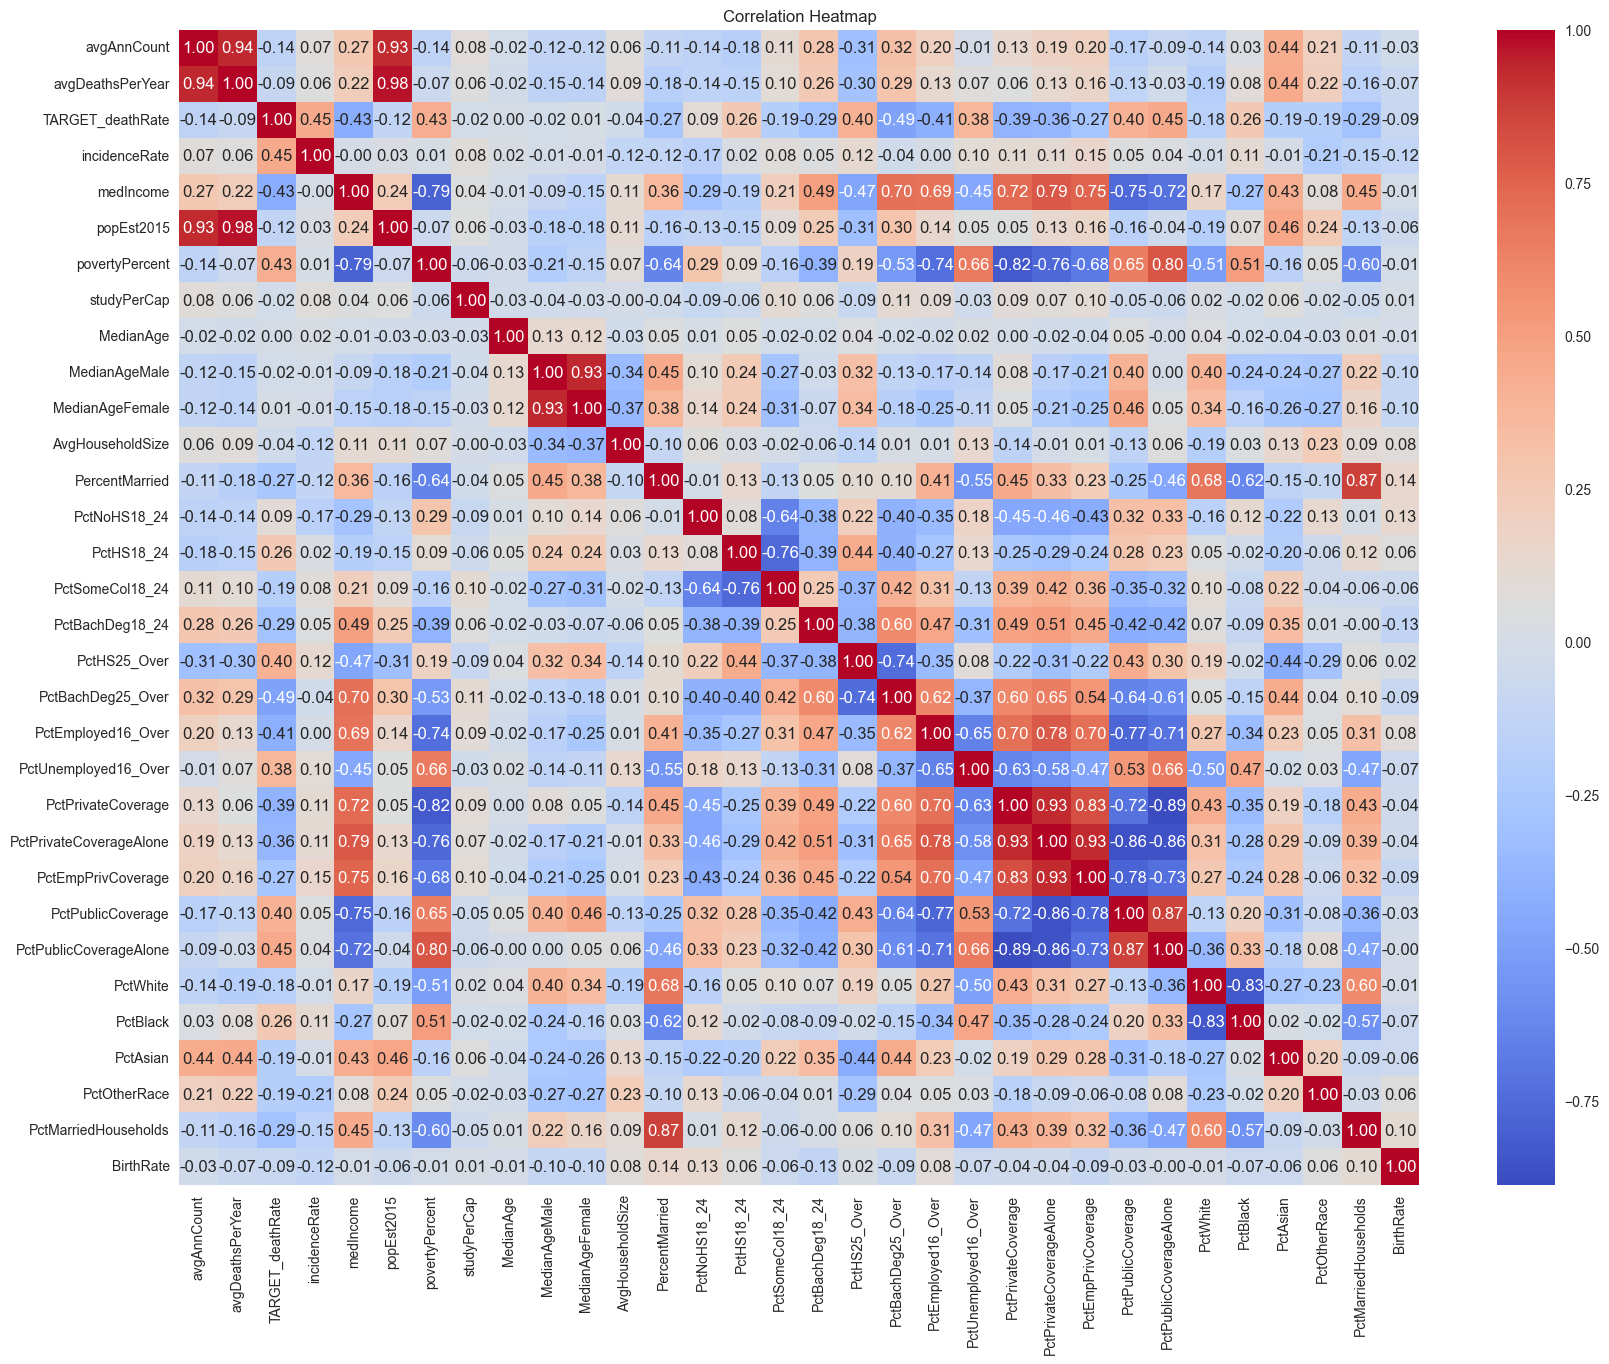

In [65]:
num = df.select_dtypes(include=[np.number])
corr = num.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## **Data Preprocessing**

1. a) Lakukan penanganan terhadap missing values, duplikasi data, dan outliers jika ada.

> Catatan:
* Mahasiswa diharapkan dapat melakukan eksplorasi preprocessing pada data sehingga dihasilkan hasil yang baik.
* Semakin baik r2 score yang dihasilkan, maka semakin baik nilai yang anda dapatkan.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Check missing values
print('\n--- Missing Values ---')
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': (missing.values / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(f'\nColumns with missing values:')
    print(missing_df.to_string(index=False))
else:
    print('\nNo missing values found!')

# Check duplicates
print('\n--- Duplicate Rows ---')
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

# Make a copy for cleaning
df_clean = df.copy()

# 1. Handle Missing Values
print('\n--- Handling Missing Values ---')

# Drop Geography column (identifier, not useful for regression)
if 'Geography' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Geography'])

# Identify numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

print(f'\nNumeric columns: {len(numeric_cols)}')
print(f'Categorical columns: {len(categorical_cols)}')

# Fill missing values with median for numeric columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

# Fill missing values with mode for categorical columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)

print(f'\n✓ Missing values after cleaning: {df_clean.isnull().sum().sum()}')

# 2. Remove Duplicates
print('\n--- Removing Duplicates ---')
before_dup = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after_dup = df_clean.shape[0]

# 3. Handle Outliers using IQR method
print('\n--- Handling Outliers (IQR Method) ---')

# Separate target variable before outlier handling
if 'TARGET_deathRate' in df_clean.columns:
    target = df_clean['TARGET_deathRate'].copy()
    features = df_clean.drop(columns=['TARGET_deathRate'])
else:
    features = df_clean.copy()
    target = None

numeric_features = features.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_features:
    Q1 = features[col].quantile(0.25)
    Q3 = features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers_count = ((features[col] < lower_bound) | (features[col] > upper_bound)).sum()
    
    if outliers_count > 0:
        # Cap outliers
        features[col] = np.where(features[col] < lower_bound, lower_bound, features[col])
        features[col] = np.where(features[col] > upper_bound, upper_bound, features[col])
        
        outlier_summary.append({
            'Column': col,
            'Outliers_Found': outliers_count,
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outliers_Found', ascending=False)
    print(f'\nOutliers detected and capped in {len(outlier_df)} columns:')
    print(outlier_df.head(10).to_string(index=False))
else:
    print('\nNo outliers detected!')

# Combine features and target back
if target is not None:
    df_clean = features.copy()
    df_clean['TARGET_deathRate'] = target
else:
    df_clean = features.copy()



--- Missing Values ---

Columns with missing values:
                 Column  Missing_Count  Missing_Percentage
        PctSomeCol18_24           2285               74.99
PctPrivateCoverageAlone            609               19.99
     PctEmployed16_Over            152                4.99

--- Duplicate Rows ---
Number of duplicate rows: 0

--- Handling Missing Values ---

Numeric columns: 32
Categorical columns: 1

✓ Missing values after cleaning: 0

--- Removing Duplicates ---

--- Handling Outliers (IQR Method) ---

Outliers detected and capped in 31 columns:
          Column  Outliers_Found  Lower_Bound  Upper_Bound
 PctSomeCol18_24             759        40.40        40.40
     studyPerCap             504      -125.48       209.13
     avgAnnCount             461      -587.00      1181.00
      popEst2015             412    -73796.50    154151.50
        PctBlack             395       -14.21        25.34
avgDeathsPerYear             349      -153.50       330.50
        PctAsian  

Penentuan fitur serta label yang akan digunakan.

In [67]:
X = df_clean.drop(columns=['TARGET_deathRate'])
y = df_clean['TARGET_deathRate']

1. b) Bagi data ke dalam data uji dan data latih dengan 80% training set menggunakan `train_test_split`.

In [68]:
# Split data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shapes:')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

Shapes:
X_train: (2437, 32)
X_test : (610, 32)
y_train: (2437,)
y_test : (610,)


1. c) Lakukan pemilihan fitur-fitur yang relevan untuk melakukan regresi serta tampilkan fitur-fitur yang terpilih.

In [69]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor


# --- Encode kolom kategorikal dengan LabelEncoder 
X_processed = X.copy()
cat_cols = X_processed.select_dtypes(include=['object', 'category']).columns.tolist()
encoders = {}
if cat_cols:
    print(f"Encoding kolom kategorikal: {cat_cols}")
for col in cat_cols:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col].astype(str))
    encoders[col] = le

# --- Pastikan tidak ada nilai inf/nan tersisa
X_processed = X_processed.replace([np.inf, -np.inf], np.nan)
X_processed = X_processed.fillna(X_processed.median(numeric_only=True))

# --- METHOD 1: Korelasi Pearson dengan target
corr_vals = []
for col in X_processed.columns:
    try:
        corr_vals.append((col, float(pd.Series(X_processed[col]).corr(y))))
    except Exception:
        corr_vals.append((col, np.nan))
corr_df = pd.DataFrame(corr_vals, columns=['Feature','Correlation'])
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)

# --- METHOD 2: F-statistic (ANOVA)
k_pick = min(15, X_processed.shape[1])
selector_f = SelectKBest(score_func=f_regression, k=k_pick)
selector_f.fit(X_processed, y)
f_df = pd.DataFrame({'Feature': X_processed.columns, 'F_Score': selector_f.scores_})
f_df = f_df.sort_values('F_Score', ascending=False)

# --- METHOD 3: Mutual Information
mi = mutual_info_regression(X_processed, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X_processed.columns, 'MI_Score': mi})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

# --- METHOD 4: Random Forest Importance
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_processed, y)
rf_df = pd.DataFrame({'Feature': X_processed.columns, 'Importance': rf.feature_importances_})
rf_df = rf_df.sort_values('Importance', ascending=False)

# --- Gabungkan 4 metode → konsensus
top_n = 15
set_corr = set(corr_df.head(top_n)['Feature'])
set_f    = set(f_df.head(top_n)['Feature'])
set_mi   = set(mi_df.head(top_n)['Feature'])
set_rf   = set(rf_df.head(top_n)['Feature'])

counts = {}
for feat in X_processed.columns:
    counts[feat] = int(feat in set_corr) + int(feat in set_f) + int(feat in set_mi) + int(feat in set_rf)

summary_df = pd.DataFrame({'Feature': list(counts.keys()), 'Method_Count': list(counts.values())})
summary_df = summary_df.sort_values('Method_Count', ascending=False)

# Ambil fitur yang muncul ≥3/4 metode; kalau terlalu sedikit, longgarkan ke ≥2
selected_features = [f for f, c in counts.items() if c >= 3]
if len(selected_features) < 10:
    selected_features = [f for f, c in counts.items() if c >= 2]

# --- Tampilkan hasil
print("\nRingkasan (20 teratas):")
print(summary_df.head(20).to_string(index=False))

print("\n" + "*"*80)
print(f"FITUR TERPILIH: {len(selected_features)} fitur")
for i, f in enumerate(sorted(selected_features), 1):
    print(f"{i:2d}. {f:30s} (muncul di {counts[f]}/4 metode)")
print("*"*80)

# --- Dataset final hanya dengan fitur terpilih (siap untuk modeling)
X_selected = X_processed[selected_features]
print(f"\nFinal Dataset:")
print(f"X_selected shape: {X_selected.shape}")
print(f"y shape        : {y.shape}")

Encoding kolom kategorikal: ['binnedInc']

Ringkasan (20 teratas):
                Feature  Method_Count
 PctPublicCoverageAlone             4
         povertyPercent             4
           PctHS25_Over             4
   PctUnemployed16_Over             4
     PctPrivateCoverage             4
      PctBachDeg25_Over             4
              medIncome             4
          incidenceRate             4
   PctMarriedHouseholds             3
     PctEmployed16_Over             3
      PctPublicCoverage             3
PctPrivateCoverageAlone             3
             PctHS18_24             3
     PctEmpPrivCoverage             2
             popEst2015             2
       avgDeathsPerYear             2
        PctBachDeg18_24             2
           PctOtherRace             1
               PctBlack             1
            avgAnnCount             1

********************************************************************************
FITUR TERPILIH: 13 fitur
 1. PctBachDeg25_Over       

## **Linear Regression**

Linear regression adalah teknik pencarian nilai-nilai parameter suatu persamaan linear yang cocok dengan data. Persamaan linear yang cocok adalah persamaan yang memiliki perbedaan hasil prediksi dan aktual minimal.

Contoh persamaan linear

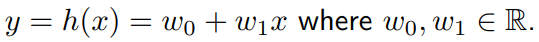

Persamaan di atas adalah fungsi yang memetakan **X** ke **Y** (anggap Y = h(x)), dengan:
- w0 adalah intersep
- w1 adalah koefisien
- x adalah variabel independen
- y adalah variabel dependen

Tentunya, persamaan ini bisa digeneralisasikan untuk banyak nilai x (fitur lebih dari 1) untuk menentukan nilai y. Berikut adalah persamaannya.

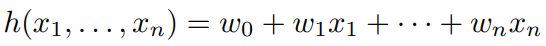

atau

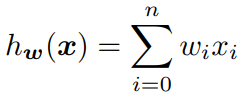

Nilai-nilai parameter seperti w0, w1, w2, wn, dst. inilah yang dicari untuk mendapatkan persamaan/fungsi yang cocok dengan data pada linear regression.

Pencarian didasarkan pada peminimalan error/residual dengan meminimal kan fungsi loss linear regression. J(w) di bawah ini adalah contoh fungsi loss linear regression.

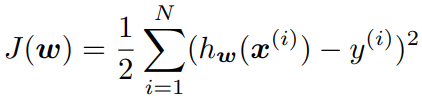

Proses peminimalan fungsi loss disebut dengan gradient descent yang bisa Anda pelajari lebih lanjut dari slide kuliah.

**Sumber gambar:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasi Linear Regression menggunakan **sklearn** dapat dilihat pada link [berikut](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

2. a) Buatlah sebuah model regresi linear berdasarkan fitur-fitur yang terpilih sebelumnya serta tampilkan hasil prediksinya pada keseluruhan data uji.

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd


# Split data menjadi train dan test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f"\nData Split (80% Train, 20% Test):")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}\n")

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediksi pada seluruh data uji
y_pred = lr_model.predict(X_test)

# Hasil prediksi (seluruh data uji)
results_df = pd.DataFrame({
    'Index'     : y_test.index,          # referensi baris asli
    'Actual'    : y_test.values,
    'Predicted' : y_pred,
    'Error'     : y_test.values - y_pred,
    'Abs_Error' : np.abs(y_test.values - y_pred)
}).reset_index(drop=True)

print(results_df.head(20).to_string(index=False))

# Koefisien model
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).reindex(columns=['Feature','Coefficient']).sort_values(
    'Coefficient', key=lambda s: s.abs(), ascending=False
)
print(f"\nIntercept (w0): {lr_model.intercept_:.6f}")
print(coefficients_df.to_string(index=False))

# Evaluasi performa
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\nEVALUASI PADA DATA UJI")
print(f"Mean Squared Error (MSE)      : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"R² Score                       : {r2:.4f} ({r2*100:.2f}%)")



Data Split (80% Train, 20% Test):
X_train shape: (2437, 13)
X_test shape : (610, 13)
y_train shape: (2437,)
y_test shape : (610,)

 Index  Actual  Predicted      Error  Abs_Error
  1582   186.5 186.093382   0.406618   0.406618
  2367   152.5 162.650000 -10.150000  10.150000
  2091   174.2 162.427300  11.772700  11.772700
   343   207.6 194.713119  12.886881  12.886881
  2661   192.0 185.962201   6.037799   6.037799
  1173   215.9 164.728389  51.171611  51.171611
  2453   178.0 167.052626  10.947374  10.947374
  1027   145.4 153.788064  -8.388064   8.388064
  1864   149.5 142.064212   7.435788   7.435788
  2765   184.8 167.410899  17.389101  17.389101
   932   123.6 136.773936 -13.173936  13.173936
   178   190.6 183.565711   7.034289   7.034289
  2320   222.2 202.773440  19.426560  19.426560
  2098   178.8 187.379671  -8.579671   8.579671
  1538   186.1 171.016440  15.083560  15.083560
  2429   204.0 194.375943   9.624057   9.624057
  2181   196.7 198.683570  -1.983570   1.983570
  23

2. b) Visualisasikan kinerja model **regresi linear** yang sudah dipilih sebelumnya pada keseluruhan data uji serta tampilkan nilai eksak dari R squared yang dihasilkan dengan menggunakan **cross validation** untuk mendapatkan performa kinerja sebenarnya menggunakan data latih yang ada.

> Catatan: Jumlah split dibebaskan.

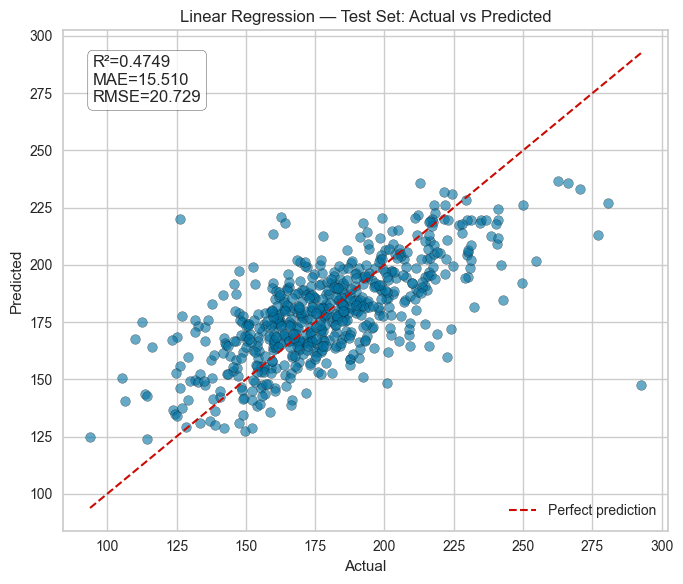


CROSS-VALIDATION (Train set, R²)
R² per fold: 0.5691, 0.5233, 0.4758, 0.4155, 0.4414, 0.5352, 0.4726, 0.4161, 0.5037, 0.4800
Mean R²     : 0.4833
Std R²      : 0.0481

RINGKASAN
Test R²             : 0.4749
Test RMSE           : 20.7290
Test MAE            : 15.5100
CV (10-fold) R² mean: 0.4833
CV (10-fold) R² std : 0.0481


In [71]:
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

y_pred = lr_model.predict(X_test)

# --- Visualisasi tunggal: Actual vs Predicted (data uji)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
_min, _max = float(min(y_test.min(), y_pred.min())), float(max(y_test.max(), y_pred.max()))
plt.plot([_min, _max], [_min, _max], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression — Test Set: Actual vs Predicted')
plt.legend()
# anotasi metrik utama di pojok
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
_r2  = r2_score(y_test, y_pred)
_mae = mean_absolute_error(y_test, y_pred)
_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
plt.text(0.05, 0.95, f'R²={_r2:.4f}\nMAE={_mae:.3f}\nRMSE={_rmse:.3f}',
         transform=plt.gca().transAxes, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

# --- Cross-validation pada data latih (R²)
# (Jumlah split bebas; gunakan 10-fold dengan shuffle agar stabil)
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='r2')

print("\nCROSS-VALIDATION (Train set, R²)")
print("=" * 80)
print(f"R² per fold: {', '.join([f'{s:.4f}' for s in cv_scores])}")
print(f"Mean R²     : {cv_scores.mean():.4f}")
print(f"Std R²      : {cv_scores.std():.4f}")

# Ringkasan akhir 
print("\nRINGKASAN")
print(f"{'Test R²':<20}: {_r2:.4f}")
print(f"{'Test RMSE':<20}: {_rmse:.4f}")
print(f"{'Test MAE':<20}: {_mae:.4f}")
print(f"{'CV (10-fold) R² mean':<20}: {cv_scores.mean():.4f}")
print(f"{'CV (10-fold) R² std':<20}: {cv_scores.std():.4f}")


## Lasso, Ridge Regression

Linear regression adalah model yang memiliki ciri high-bias dan low-variance. Biasanya, model seperti ini cenderung tidak overfit. Walau demikian, linear regression masih dapat mengalami overfitting, apalagi pada data yang memiliki banyak fitur (high-dimension).

Untuk mengatasi hal tersebut, diperlukan regularisasi. Pada linear regression, regularisasi adalah teknik untuk meminimalkan fungsi loss dengan penambahan regularization term pada fungsi loss. Dua teknik regularisasi pada linear regression adalah Ridge dan Lasso. Berikut adalah modifikasi fungsi loss linear regression pada ridge dan lasso regression.

- Ridge regression

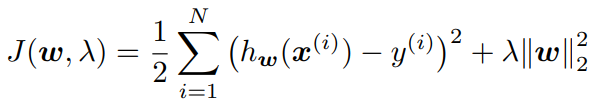

- Lasso Regression

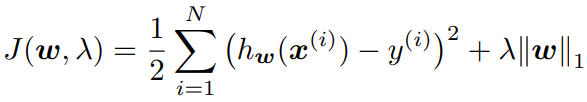

Term tambahan pada fungsi loss tersebut berperan seperti bobot pinalti untuk meminimalkan overfitting. Pada regularization term terdapat parameter λ yang pada sumber lain disebut sebagai α (alpha).

**Sumber gambar:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasinya menggunakan **sklearn** dapat dilihat pada kedua link berikut:
* [Lasso Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html).
* [Ridge Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

### **Lasso Regression**

3. a) Buatlah sebuah list alpha yang berisi minimal 5 buah alpha.

In [72]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Create list with at least 5 alpha values
alphas_lasso = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
print(f"Alpha values for Lasso: {alphas_lasso}")
print(f"Total number of alphas: {len(alphas_lasso)}")


Alpha values for Lasso: [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
Total number of alphas: 9


3. b) Buatlah (fit) model regresi lasso berdasarkan fitur-fitur yang terpilih di awal sebanyak nilai alpha yang telah ditentukan.

In [73]:

lasso_models = {}
lasso_predictions = {}

for alpha in alphas_lasso:
    # Create and train model
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train, y_train)
    
    # Store model and predictions
    lasso_models[alpha] = lasso
    lasso_predictions[alpha] = lasso.predict(X_test)
    
    print(f"Trained Lasso model with alpha = {alpha}")

print(f"\nTotal {len(lasso_models)} Lasso models trained successfully!")

Trained Lasso model with alpha = 0.001
Trained Lasso model with alpha = 0.01
Trained Lasso model with alpha = 0.1
Trained Lasso model with alpha = 1
Trained Lasso model with alpha = 10
Trained Lasso model with alpha = 50
Trained Lasso model with alpha = 100
Trained Lasso model with alpha = 500
Trained Lasso model with alpha = 1000

Total 9 Lasso models trained successfully!


3. c) Tampilkan nilai MAE, MSE, RMSE, dan R-squared untuk masing-masing model pada testing set

In [74]:

lasso_results = []

for alpha in alphas_lasso:
    y_pred = lasso_predictions[alpha]
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    lasso_results.append({
        'Alpha': alpha,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f"\nAlpha = {alpha:>8}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

# Create DataFrame for easy comparison
lasso_results_df = pd.DataFrame(lasso_results)
print("\nSUMMARY TABLE: Lasso Regression Performance")
print(lasso_results_df.to_string(index=False))


Alpha =    0.001
  MAE  : 15.5100
  MSE  : 429.6913
  RMSE : 20.7290
  R²   : 0.4749

Alpha =     0.01
  MAE  : 15.5103
  MSE  : 429.6903
  RMSE : 20.7290
  R²   : 0.4749

Alpha =      0.1
  MAE  : 15.5135
  MSE  : 429.6862
  RMSE : 20.7289
  R²   : 0.4749

Alpha =        1
  MAE  : 15.5513
  MSE  : 430.2161
  RMSE : 20.7417
  R²   : 0.4742

Alpha =       10
  MAE  : 15.8603
  MSE  : 443.7362
  RMSE : 21.0650
  R²   : 0.4577

Alpha =       50
  MAE  : 16.6473
  MSE  : 472.1600
  RMSE : 21.7292
  R²   : 0.4230

Alpha =      100
  MAE  : 16.6679
  MSE  : 475.0984
  RMSE : 21.7968
  R²   : 0.4194

Alpha =      500
  MAE  : 18.3329
  MSE  : 578.7955
  RMSE : 24.0582
  R²   : 0.2926

Alpha =     1000
  MAE  : 19.1640
  MSE  : 633.1676
  RMSE : 25.1628
  R²   : 0.2262

SUMMARY TABLE: Lasso Regression Performance
   Alpha       MAE        MSE      RMSE       R²
   0.001 15.509989 429.691336 20.728997 0.474862
   0.010 15.510304 429.690346 20.728974 0.474864
   0.100 15.513454 429.686168 20.7

3. d) Pilih model terbaik berdasarkan nilai R-squared yang ditampilkan.

In [75]:

best_lasso_idx = lasso_results_df['R²'].idxmax()
best_lasso_alpha = lasso_results_df.loc[best_lasso_idx, 'Alpha']
best_lasso_r2 = lasso_results_df.loc[best_lasso_idx, 'R²']
best_lasso_model = lasso_models[best_lasso_alpha]

print(f"\nBEST LASSO MODEL:")
print(f"   Alpha: {best_lasso_alpha}")
print(f"   R² Score: {best_lasso_r2:.4f}")
print(f"\n   Complete metrics:")
print(lasso_results_df.loc[best_lasso_idx].to_string())


BEST LASSO MODEL:
   Alpha: 0.1
   R² Score: 0.4749

   Complete metrics:
Alpha      0.100000
MAE       15.513454
MSE      429.686168
RMSE      20.728873
R²         0.474869


3. e) Tampilkan array hasil prediksi dari model ridge yang terpilih pada keseluruhan data uji.

In [76]:
best_lasso_predictions = lasso_predictions[best_lasso_alpha]

print(f"\nBest Lasso Model Predictions (alpha = {best_lasso_alpha}):")
print(f"Shape: {best_lasso_predictions.shape}")
print(f"\nFirst 20 predictions:")
print(best_lasso_predictions[:20])
print(f"\nLast 20 predictions:")
print(best_lasso_predictions[-20:])

print(f"\nPrediction Statistics:")
print(f"  Mean     : {best_lasso_predictions.mean():.4f}")
print(f"  Std      : {best_lasso_predictions.std():.4f}")
print(f"  Min      : {best_lasso_predictions.min():.4f}")
print(f"  Max      : {best_lasso_predictions.max():.4f}")
print(f"  Median   : {np.median(best_lasso_predictions):.4f}")

# Create comparison DataFrame
lasso_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_lasso_predictions,
    'Difference': y_test.values - best_lasso_predictions,
    'Abs_Error': np.abs(y_test.values - best_lasso_predictions)
})

print(f"\nComparison Table (First 20 samples):")
print(lasso_comparison.head(20).to_string(index=False))



Best Lasso Model Predictions (alpha = 0.1):
Shape: (610,)

First 20 predictions:
[186.11139628 162.57070328 162.44829938 194.87142072 185.83068291
 164.60425655 167.19494712 153.79069889 142.0612824  167.37577444
 136.77800392 183.64501373 202.7042003  187.32146903 171.04184402
 194.30454523 198.6147325  179.08219277 219.37225711 179.90595247]

Last 20 predictions:
[167.43343885 156.43742738 167.41722713 157.12977645 158.21006678
 196.01666528 219.63429885 173.46117269 187.52101516 202.84485812
 178.89308986 166.92102306 178.84002566 175.39739118 179.86689994
 202.33626181 212.59510229 181.3330345  164.37163663 177.79454275]

Prediction Statistics:
  Mean     : 178.8851
  Std      : 21.1561
  Min      : 123.9300
  Max      : 236.3391
  Median   : 178.2532

Comparison Table (First 20 samples):
 Actual  Predicted  Difference  Abs_Error
  186.5 186.111396    0.388604   0.388604
  152.5 162.570703  -10.070703  10.070703
  174.2 162.448299   11.751701  11.751701
  207.6 194.871421   12.728

3. f) Visualisasikan kinerja model **regresi lasso** yang sudah dipilih sebelumnya pada keseluruhan data uji serta tampilkan nilai eksak dari R squared yang dihasilkan dengan menggunakan **cross validation** untuk mendapatkan performa kinerja sebenarnya menggunakan data latih yang ada.

> Catatan: Jumlah split dibebaskan.

R² (test) : 0.4749

Cross Validation R² (Train set):
  Mean : 0.4834
  Std  : 0.0481
  Min  : 0.4156
  Max  : 0.5695

Cross Validation R² (Train set):
  Mean : 0.4834
  Std  : 0.0481
  Min  : 0.4156
  Max  : 0.5695


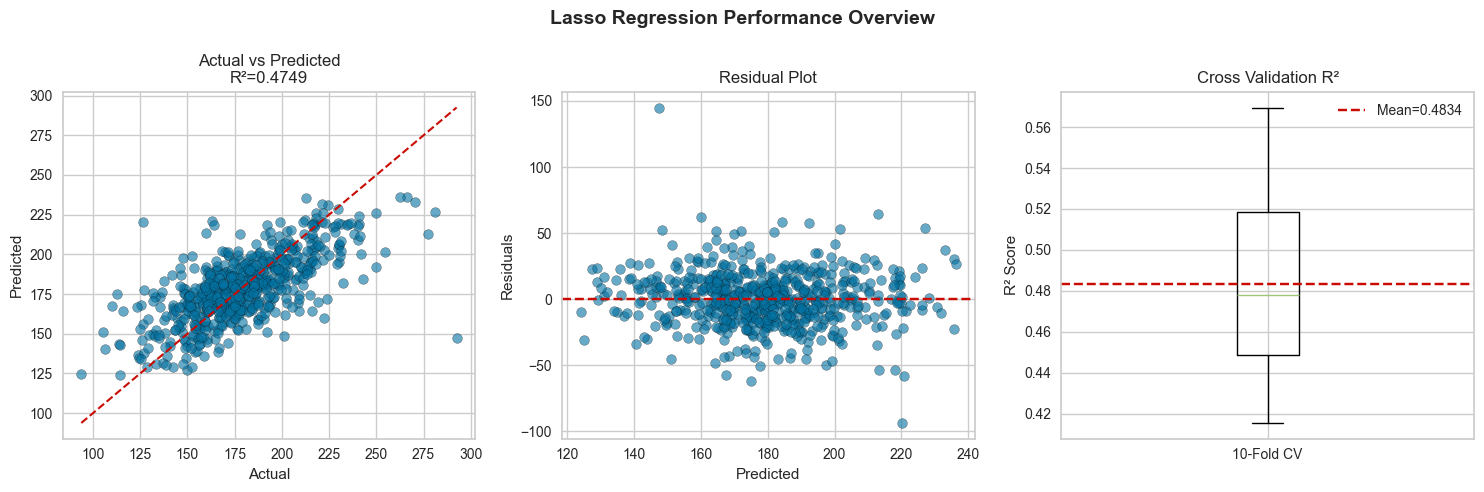

In [77]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# --- Prediksi di data uji
y_pred_lasso = best_lasso_model.predict(X_test)
r2_test = r2_score(y_test, y_pred_lasso)
print(f"R² (test) : {r2_test:.4f}")

# --- Cross-validation (10-fold di data latih)
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_lasso_model, X_train, y_train, cv=cv, scoring='r2')

print(f"\nCross Validation R² (Train set):")
print(f"  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")
print(f"  Min  : {cv_scores.min():.4f}")
print(f"  Max  : {cv_scores.max():.4f}")

# --- Visualisasi: 3 plot sederhana
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle("Lasso Regression Performance Overview", fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_lasso, alpha=0.6, edgecolors='k')
lo, hi = float(min(y_test.min(), y_pred_lasso.min())), float(max(y_test.max(), y_pred_lasso.max()))
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted\nR²={r2_test:.4f}')

# Plot 2: Residuals
resid = y_test - y_pred_lasso
axes[1].scatter(y_pred_lasso, resid, alpha=0.6, edgecolors='k')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

# Plot 3: Cross-Validation R²
axes[2].boxplot(cv_scores, labels=['10-Fold CV'])
axes[2].axhline(cv_scores.mean(), color='r', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
axes[2].set_ylabel('R² Score')
axes[2].set_title('Cross Validation R²')
axes[2].legend()

plt.tight_layout()
plt.show()

3. g) Berikan analisis hubungan perubahan nilai parameter alpha dengan kualitas hasil regresi berdasarkan nilai R-squared

Jawaban:

Berdasarkan hasil pengujian model Lasso Regression, perubahan nilai alpha (α) menunjukkan hubungan terbalik dengan kualitas model yang diukur melalui nilai R². Saat α bernilai kecil, penalti regularisasi masih lemah sehingga model lebih fleksibel dalam menyesuaikan data, menghasilkan nilai R² yang lebih tinggi namun berpotensi overfitting. Sebaliknya, ketika α meningkat, penalti regularisasi semakin kuat, banyak koefisien mendekati nol, dan model menjadi lebih sederhana namun kehilangan sebagian kemampuan menjelaskan variasi data, sehingga R² menurun. Nilai α optimal diperoleh pada titik tengah di mana R² masih tinggi dengan kompleksitas model yang terkendali, mencerminkan keseimbangan yang baik antara bias dan variansi serta menghasilkan performa yang stabil pada data uji dan cross-validation.

### **Ridge Regression**

4. a) Buatlah sebuah list alpha yang berisi minimal 5 buah alpha.

In [78]:
from sklearn.linear_model import Ridge

# Create list with at least 5 alpha values
alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
print(f"Alpha values for Ridge: {alphas_ridge}")
print(f"Total number of alphas: {len(alphas_ridge)}")

Alpha values for Ridge: [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
Total number of alphas: 9


4. b) Buatlah model regresi ridge berdasarkan fitur-fitur yang terpilih di awal sebanyak nilai alpha yang telah ditentukan.

> Catatan: Abaikan warning mengenai ill-conditioned matrix jika ada.

In [79]:

ridge_models = {}
ridge_predictions = {}

for alpha in alphas_ridge:
    # Create and train model
    ridge = Ridge(alpha=alpha, max_iter=10000, random_state=42)
    ridge.fit(X_train, y_train)
    
    # Store model and predictions
    ridge_models[alpha] = ridge
    ridge_predictions[alpha] = ridge.predict(X_test)
    
    print(f"Trained Ridge model with alpha = {alpha}")


Trained Ridge model with alpha = 0.001
Trained Ridge model with alpha = 0.01
Trained Ridge model with alpha = 0.1
Trained Ridge model with alpha = 1
Trained Ridge model with alpha = 10
Trained Ridge model with alpha = 50
Trained Ridge model with alpha = 100
Trained Ridge model with alpha = 500
Trained Ridge model with alpha = 1000


4. c) Tampilkan nilai MAE, MSE, RMSE, dan R-squared untuk masing-masing model pada testing set

In [80]:

ridge_results = []

for alpha in alphas_ridge:
    y_pred = ridge_predictions[alpha]
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    ridge_results.append({
        'Alpha': alpha,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f"\nAlpha = {alpha:>8}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

ridge_results_df = pd.DataFrame(ridge_results)
print("\nSUMMARY TABLE: Ridge Regression Performance")
print(ridge_results_df.to_string(index=False))


Alpha =    0.001
  MAE  : 15.5100
  MSE  : 429.6915
  RMSE : 20.7290
  R²   : 0.4749

Alpha =     0.01
  MAE  : 15.5100
  MSE  : 429.6914
  RMSE : 20.7290
  R²   : 0.4749

Alpha =      0.1
  MAE  : 15.5100
  MSE  : 429.6914
  RMSE : 20.7290
  R²   : 0.4749

Alpha =        1
  MAE  : 15.5100
  MSE  : 429.6907
  RMSE : 20.7290
  R²   : 0.4749

Alpha =       10
  MAE  : 15.5099
  MSE  : 429.6842
  RMSE : 20.7288
  R²   : 0.4749

Alpha =       50
  MAE  : 15.5098
  MSE  : 429.6556
  RMSE : 20.7281
  R²   : 0.4749

Alpha =      100
  MAE  : 15.5096
  MSE  : 429.6206
  RMSE : 20.7273
  R²   : 0.4749

Alpha =      500
  MAE  : 15.5084
  MSE  : 429.3650
  RMSE : 20.7211
  R²   : 0.4753

Alpha =     1000
  MAE  : 15.5070
  MSE  : 429.0957
  RMSE : 20.7146
  R²   : 0.4756

SUMMARY TABLE: Ridge Regression Performance
   Alpha       MAE        MSE      RMSE       R²
   0.001 15.509954 429.691451 20.729000 0.474862
   0.010 15.509954 429.691445 20.729000 0.474862
   0.100 15.509954 429.691380 20.7

4. d) Pilih model terbaik berdasarkan nilai R-squared yang ditampilkan.

In [81]:
best_ridge_idx = ridge_results_df['R²'].idxmax()
best_ridge_alpha = ridge_results_df.loc[best_ridge_idx, 'Alpha']
best_ridge_r2 = ridge_results_df.loc[best_ridge_idx, 'R²']
best_ridge_model = ridge_models[best_ridge_alpha]

print(f"\nBEST RIDGE MODEL:")
print(f"   Alpha: {best_ridge_alpha}")
print(f"   R² Score: {best_ridge_r2:.4f}")
print(f"\n   Complete metrics:")
print(ridge_results_df.loc[best_ridge_idx].to_string())


BEST RIDGE MODEL:
   Alpha: 1000.0
   R² Score: 0.4756

   Complete metrics:
Alpha    1000.000000
MAE        15.507046
MSE       429.095674
RMSE       20.714625
R²          0.475590


4. e) Tampilkan array hasil prediksi dari model ridge yang terpilih pada keseluruhan data uji.

In [82]:

best_ridge_predictions = ridge_predictions[best_ridge_alpha]

print(f"\nBest Ridge Model Predictions (alpha = {best_ridge_alpha}):")
print(f"Shape: {best_ridge_predictions.shape}")
print(f"\nFirst 20 predictions:")
print(best_ridge_predictions[:20])
print(f"\nLast 20 predictions:")
print(best_ridge_predictions[-20:])

print(f"\nPrediction Statistics:")
print(f"  Mean     : {best_ridge_predictions.mean():.4f}")
print(f"  Std      : {best_ridge_predictions.std():.4f}")
print(f"  Min      : {best_ridge_predictions.min():.4f}")
print(f"  Max      : {best_ridge_predictions.max():.4f}")
print(f"  Median   : {np.median(best_ridge_predictions):.4f}")

# Create comparison DataFrame
ridge_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_ridge_predictions,
    'Difference': y_test.values - best_ridge_predictions,
    'Abs_Error': np.abs(y_test.values - best_ridge_predictions)
})

print(f"\nComparison Table (First 20 samples):")
print(ridge_comparison.head(20).to_string(index=False))


Best Ridge Model Predictions (alpha = 1000.0):
Shape: (610,)

First 20 predictions:
[186.051738   162.6115964  162.62012592 194.98498144 185.57087842
 164.45587578 167.41315628 153.88898702 142.34366354 167.27222666
 136.93942787 183.95334374 202.54154715 187.19025175 171.13441472
 194.09685914 198.42521628 179.0888868  219.45069768 179.82811121]

Last 20 predictions:
[167.35352054 156.39847491 167.44595231 157.21787845 158.17416617
 195.75398608 219.39807306 173.53782515 187.48262429 202.81935825
 178.85070619 166.84836994 178.83792594 175.40783336 180.03811958
 202.2896628  212.31384952 181.26811402 164.24943148 178.21838409]

Prediction Statistics:
  Mean     : 178.8837
  Std      : 21.1207
  Min      : 123.7462
  Max      : 236.4140
  Median   : 178.2900

Comparison Table (First 20 samples):
 Actual  Predicted  Difference  Abs_Error
  186.5 186.051738    0.448262   0.448262
  152.5 162.611596  -10.111596  10.111596
  174.2 162.620126   11.579874  11.579874
  207.6 194.984981   12.

4. f) Visualisasikan kinerja model **regresi ridge** yang sudah dipilih sebelumnya pada keseluruhan data uji serta tampilkan nilai eksak dari R squared yang dihasilkan dengan menggunakan **cross validation** untuk mendapatkan performa kinerja sebenarnya menggunakan data latih yang ada.

> Catatan: Jumlah split dibebaskan

Test R²                : 0.4756
CV R² (10-fold) mean   : 0.4837
CV R² (10-fold) std    : 0.0477
CV R² (min, max)       : 0.4170, 0.5697


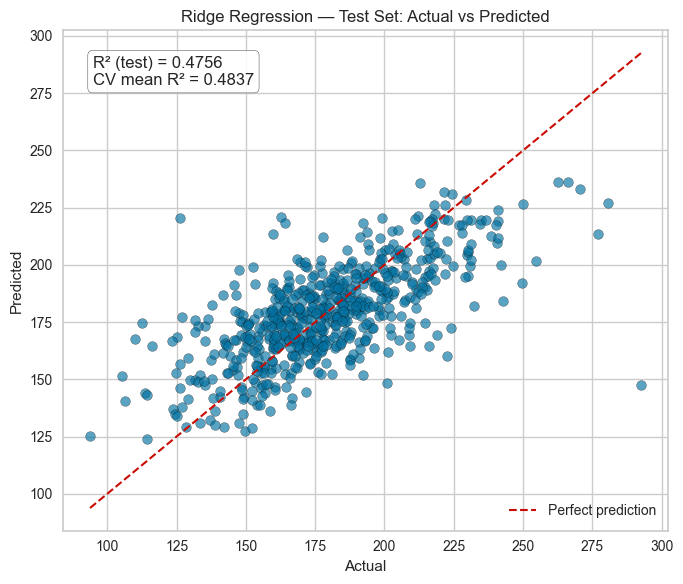

In [83]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Prediksi di data uji (tanpa retrain)
y_pred_ridge = best_ridge_model.predict(X_test)
r2_test_ridge = r2_score(y_test, y_pred_ridge)

# Cross-Validation R² pada data latih (jumlah split bebas → pakai 10)
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_ridge = cross_val_score(best_ridge_model, X_train, y_train, cv=cv, scoring='r2')

print(f"Test R²                : {r2_test_ridge:.4f}")
print(f"CV R² (10-fold) mean   : {cv_scores_ridge.mean():.4f}")
print(f"CV R² (10-fold) std    : {cv_scores_ridge.std():.4f}")
print(f"CV R² (min, max)       : {cv_scores_ridge.min():.4f}, {cv_scores_ridge.max():.4f}")

# Satu visual: Actual vs Predicted pada test set + anotasi R²
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.65, edgecolors='k')
lo = float(min(y_test.min(), y_pred_ridge.min()))
hi = float(max(y_test.max(), y_pred_ridge.max()))
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Ridge Regression — Test Set: Actual vs Predicted')
plt.legend()
plt.text(0.05, 0.95,
         f'R² (test) = {r2_test_ridge:.4f}\nCV mean R² = {cv_scores_ridge.mean():.4f}',
         transform=plt.gca().transAxes, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
plt.tight_layout()
plt.show()

4. g) Berikan analisis hubungan perubahan nilai parameter alpha dengan kualitas hasil regresi berdasarkan nilai R-squared

Jawaban:

Berdasarkan hasil pengujian model Ridge Regression, dapat disimpulkan bahwa perubahan nilai alpha (α) memiliki pengaruh yang jelas terhadap kualitas model yang diukur melalui nilai R². Ketika nilai α kecil, penalti regularisasi yang dikenakan pada koefisien regresi masih lemah, sehingga model menjadi lebih kompleks dan mampu menyesuaikan data dengan lebih baik, menghasilkan nilai R² yang lebih tinggi. Namun, jika α terlalu kecil, model berisiko mengalami overfitting. Sebaliknya, ketika α meningkat, regularisasi semakin kuat dan banyak koefisien mendekati nol, sehingga model menjadi lebih sederhana dan stabil, tetapi R² cenderung menurun karena kemampuan model menjelaskan variansi data ikut berkurang. Nilai α optimal ditemukan di titik tengah, di mana R² pada data uji (≈0.476) dan rata-rata R² cross-validation (≈0.484) menunjukkan keseimbangan yang baik antara kompleksitas dan generalisasi model.

4. h) Jelaskan mengapa lasso regression dapat dijadikan model untuk feature selection, sedangkan ridge regression tidak?

Jawaban:

Lasso regression dapat dijadikan model untuk feature selection karena menggunakan regularisasi L1 yang dapat menyusutkan koefisien beberapa fitur menjadi tepat nol, sehingga fitur-fitur tersebut dianggap tidak berpengaruh dan secara otomatis dikeluarkan dari model. Hal ini menjadikan Lasso efektif dalam memilih fitur penting dan menyederhanakan model. Sebaliknya, ridge regression menggunakan regularisasi L2 yang hanya menyusutkan koefisien mendekati nol tetapi tidak pernah menjadi nol secara tepat, sehingga tidak mengeliminasi fitur secara langsung dan tidak cocok untuk feature selection meskipun dapat mengurangi kompleksitas model. Dengan demikian, kemampuan Lasso menetapkan koefisien fitur menjadi nol membuatnya unggul untuk seleksi fitur dibandingkan dengan ridge regression yang koefisiennya tetap non-nol meski kecil.

- https://youtu.be/6JIE2BsDELU
- https://dqlab.id/5-hal-menarik-lasso-regression-model-machine-learning

## **Logistic, Softmax Regression**

Logistic dan Softmax merupakan jenis regresi yang menghasilkan output diskrit yang dapat berupa binary classification maupun multiclass classification.

### **Logistic Regression**

Logistic regression adalah model linear yang hanya memiliki dua nilai output: 0 atau 1. Oleh karena itu logistic regression lebih cocok dianggap sebagai classifier daripada regressor. Contoh visualisasinya adalah sebagai berikut.

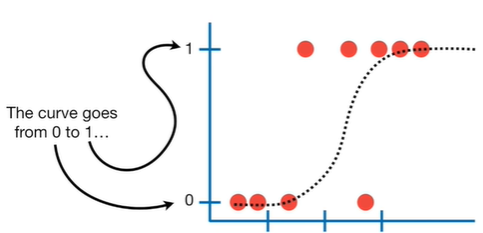

Sumber: https://youtu.be/yIYKR4sgzI8?t=222

Untuk mendapatkan kurva seperti pada gambar, berikut adalah persamaan logistic regression yang memenuhi.

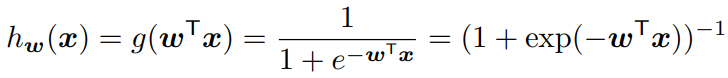

Berbeda dengan model linear, ridge, dan lasso regression yang meminimalkan fungsi loss. Pada logistic regression dilakukan proses memaksimalkan fungsi likelihood untuk menemukan parameter yang cocok dengan data.

Hal ini karena logistic regression merupakan metode klasifikasi. Sehingga, alih-alih meminimalkan perbedaan hasil prediksi, di sini memaksimalkan persamaan hasil prediksi dengan aktual.

Fungsi/persamaan likelihood dimaksimalkan melalui proses yang disebut dengan gradient ascent (tentunya bisa dipelajari sendiri dari slide :D). Berikut adalah persamaan likelihood tersebut.

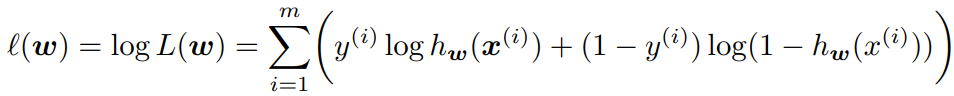

**Sumber gambar (persamaan) dan penjelasan lebih detail:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasi Logistic Regression menggunakan **sklearn** dapat dilihat pada link [berikut](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [84]:
df_logistic = pd.read_csv('spotifyreccomendation.csv').drop(columns=['title', 'first_artists', 'all_artists'])
df_logistic.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,like
0,0.486,0.881,2,-5.623,0,0.0474,0.024400,0.000000,0.429,0.6670,144.997,480707,4,1
1,0.356,0.960,4,-3.487,1,0.1040,0.014200,0.000000,0.209,0.0857,125.921,204733,4,1
2,0.487,0.949,2,-4.217,0,0.0798,0.000429,0.000029,0.231,0.4060,110.020,352427,4,1
3,0.366,0.963,11,-5.301,0,0.1420,0.000273,0.012200,0.115,0.2110,137.114,366213,4,1
4,0.412,0.920,9,-4.852,0,0.0575,0.000456,0.002600,0.110,0.4550,93.162,227440,4,1


In [85]:
df_logistic.like.value_counts()

like
0    151
1    150
Name: count, dtype: int64

In [86]:
print(df_logistic.isna().any())
print()
print(f'Length of the data: {len(df_logistic)}')
print()
df_logistic.info()

danceability        False
energy              False
key                 False
loudness            False
mode                False
speechiness         False
acousticness        False
instrumentalness    False
liveness            False
valence             False
tempo               False
duration_ms         False
time_signature      False
like                False
dtype: bool

Length of the data: 301

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      301 non-null    float64
 1   energy            301 non-null    float64
 2   key               301 non-null    int64  
 3   loudness          301 non-null    float64
 4   mode              301 non-null    int64  
 5   speechiness       301 non-null    float64
 6   acousticness      301 non-null    float64
 7   instrumentalness  301 non-null    float64
 8   liveness          

In [87]:
X_logistic = df_logistic.drop(columns=['like'])
y_logistic = df_logistic.like

5. a) Bagi data ke dalam training dan test set dengan ukuran training sebesar 80% dari jumlah data.

In [88]:

from sklearn.model_selection import train_test_split


X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_logistic, y_logistic, test_size=0.2, random_state=42, stratify=y_logistic
)

print(f"X_train shape : {X_train_log.shape}")
print(f"X_test shape  : {X_test_log.shape}")
print(f"y_train shape : {y_train_log.shape}")
print(f"y_test shape  : {y_test_log.shape}")


X_train shape : (240, 13)
X_test shape  : (61, 13)
y_train shape : (240,)
y_test shape  : (61,)


#### Pembuatan Model dengan Data Asli

5. b) Buatlah suatu model logistic regression berdasarkan data asli serta tampilkan `hasil prediksi`, `confusion matrix`, dan `hasil evaluasi metriknya`. Setelah itu, lakukan **cross validation** untuk menilai performa sebenarnya dari model menggunakan data latih yang ada.

> `hasil evaluasi metriknya` mencakup:
* F1 Macro Average,
* F1 Micro Average,
* Precision Macro Average
* Precision Micro Average
* Recall Macro Average
* Recall Micro Average

> Scoring dari cross validation:
* Accuracy
* F1 Macro
* Recall Macro

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd

# Model sederhana dengan standardisasi 
log_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("lr", LogisticRegression(max_iter=1000, n_jobs=-1))
])

# Train
log_clf.fit(X_train_log, y_train_log)

# Predict
y_pred_log = log_clf.predict(X_test_log)

# Confusion Matrix
cm = confusion_matrix(y_test_log, y_pred_log)

# Metrics (macro & micro)
acc  = accuracy_score(y_test_log, y_pred_log)
f1_macro = f1_score(y_test_log, y_pred_log, average="macro")
f1_micro = f1_score(y_test_log, y_pred_log, average="micro")
prec_macro = precision_score(y_test_log, y_pred_log, average="macro", zero_division=0)
prec_micro = precision_score(y_test_log, y_pred_log, average="micro", zero_division=0)
rec_macro = recall_score(y_test_log, y_pred_log, average="macro")
rec_micro = recall_score(y_test_log, y_pred_log, average="micro")

print("\nHasil Prediksi (head):")
print(pd.DataFrame({
    "Actual": y_test_log.values,
    "Pred"  : y_pred_log
}).head(20).to_string(index=False))

print("\nConfusion Matrix:")
print(pd.DataFrame(cm))

print("\nMetrik Evaluasi (Test Set):")
print(f"Accuracy              : {acc:.4f}")
print(f"F1 Macro Average      : {f1_macro:.4f}")
print(f"F1 Micro Average      : {f1_micro:.4f}")
print(f"Precision Macro Avg   : {prec_macro:.4f}")
print(f"Precision Micro Avg   : {prec_micro:.4f}")
print(f"Recall Macro Avg      : {rec_macro:.4f}")
print(f"Recall Micro Avg      : {rec_micro:.4f}")

# ------------------------------ Cross-Validation ------------------------------
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_validate(
    log_clf, X_train_log, y_train_log,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro", "recall_macro": "recall_macro"},
    n_jobs=-1,
    return_train_score=False
)

print("\nCross-Validation (Train set):")
print(f"Accuracy   : mean={cv_scores['test_accuracy'].mean():.4f}  std={cv_scores['test_accuracy'].std():.4f}")
print(f"F1 Macro   : mean={cv_scores['test_f1_macro'].mean():.4f}  std={cv_scores['test_f1_macro'].std():.4f}")
print(f"Recall Macro: mean={cv_scores['test_recall_macro'].mean():.4f}  std={cv_scores['test_recall_macro'].std():.4f}")

# Simpan hasil penting
logistic_results = {
    "model": log_clf,
    "y_pred": y_pred_log,
    "confusion_matrix": cm,
    "metrics_test": {
        "accuracy": acc,
        "f1_macro": f1_macro, "f1_micro": f1_micro,
        "precision_macro": prec_macro, "precision_micro": prec_micro,
        "recall_macro": rec_macro, "recall_micro": rec_micro
    },
    "cv_scores": cv_scores
}


Hasil Prediksi (head):
 Actual  Pred
      0     0
      0     0
      0     1
      0     0
      0     0
      0     1
      1     0
      0     1
      1     1
      0     1
      1     0
      0     0
      0     0
      1     0
      1     0
      1     0
      1     0
      0     0
      1     0
      1     1

Confusion Matrix:
    0   1
0  25   6
1  13  17

Metrik Evaluasi (Test Set):
Accuracy              : 0.6885
F1 Macro Average      : 0.6831
F1 Micro Average      : 0.6885
Precision Macro Avg   : 0.6985
Precision Micro Avg   : 0.6885
Recall Macro Avg      : 0.6866
Recall Micro Avg      : 0.6885

Cross-Validation (Train set):
Accuracy   : mean=0.7708  std=0.1058
F1 Macro   : mean=0.7686  std=0.1077
Recall Macro: mean=0.7708  std=0.1058

Cross-Validation (Train set):
Accuracy   : mean=0.7708  std=0.1058
F1 Macro   : mean=0.7686  std=0.1077
Recall Macro: mean=0.7708  std=0.1058


#### Pembuatan Model dengan Data yang Dinormalisasi

5. c) Lakukan normalisasi terhadap data fitur yang akan digunakan.

In [90]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# Fit hanya pada data training, lalu transform kedua dataset
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

# Ubah hasil ke DataFrame agar lebih mudah dibaca
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_log.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_log.columns)

print(f"X_train_scaled shape: {X_train_scaled_df.shape}")
print(f"X_test_scaled shape : {X_test_scaled_df.shape}")

print("\nContoh hasil normalisasi (5 baris pertama):")
print(X_train_scaled_df.head())


X_train_scaled shape: (240, 13)
X_test_scaled shape : (61, 13)

Contoh hasil normalisasi (5 baris pertama):
   danceability    energy       key  loudness      mode  speechiness  \
0     -0.467308  0.528869 -0.628635  0.430793  0.767726    -0.460129   
1     -0.841082  0.957431  0.231854  0.534040  0.767726     1.227447   
2     -2.774646 -1.071677 -0.628635 -0.721668  0.767726    -0.565340   
3     -2.508691  0.511377 -0.341805  0.052964  0.767726    -0.409628   
4     -1.545503 -1.412778 -0.628635 -0.483084  0.767726    -0.565340   

   acousticness  instrumentalness  liveness   valence     tempo  duration_ms  \
0     -0.841612         -0.190192 -0.722426 -0.537378  0.201096    -0.505732   
1     -0.804658         -0.190209 -1.214203  1.086540 -1.661484    -0.171018   
2     -0.379523         -0.158769 -0.620655 -1.751979  0.553028     1.171260   
3     -0.810218         -0.186326  2.731399 -0.715341 -1.437678     0.758348   
4      1.343908         -0.190226 -0.570837 -1.925938 -0.74

5. d) Buatlah suatu model logistic regression berdasarkan data yang sudah di normalisasi serta tampilkan `hasil prediksi`, `confusion matrix`, dan `hasil evaluasi metriknya`. Setelah itu, lakukan **cross validation** untuk menilai performa sebenarnya dari model menggunakan data latih yang ada.

>`hasil evaluasi metriknya` mencakup:
* F1 Macro Average,
* F1 Micro Average,
* Precision Macro Average
* Precision Micro Average
* Recall Macro Average
* Recall Micro Average

> Scoring dari cross validation:
* Accuracy
* F1 Macro
* Recall Macro



In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# ---------------------- Train & evaluate on scaled data ----------------------
lr_scaled = LogisticRegression(max_iter=1000, solver="lbfgs")
lr_scaled.fit(X_train_scaled_df, y_train_log)

y_pred_log_scaled = lr_scaled.predict(X_test_scaled_df)

# Confusion matrix
cm_scaled = confusion_matrix(y_test_log, y_pred_log_scaled)

# Metrics (macro & micro)
acc  = accuracy_score(y_test_log, y_pred_log_scaled)
f1_macro = f1_score(y_test_log, y_pred_log_scaled, average="macro")
f1_micro = f1_score(y_test_log, y_pred_log_scaled, average="micro")
prec_macro = precision_score(y_test_log, y_pred_log_scaled, average="macro", zero_division=0)
prec_micro = precision_score(y_test_log, y_pred_log_scaled, average="micro", zero_division=0)
rec_macro = recall_score(y_test_log, y_pred_log_scaled, average="macro")
rec_micro = recall_score(y_test_log, y_pred_log_scaled, average="micro")

print("\nHasil Prediksi (head):")
print(pd.DataFrame({"Actual": y_test_log.values, "Pred": y_pred_log_scaled}).head(20).to_string(index=False))

print("\nConfusion Matrix:")
print(pd.DataFrame(cm_scaled))

print("\nMetrik Evaluasi (Test Set, scaled):")
print(f"Accuracy              : {acc:.4f}")
print(f"F1 Macro Average      : {f1_macro:.4f}")
print(f"F1 Micro Average      : {f1_micro:.4f}")
print(f"Precision Macro Avg   : {prec_macro:.4f}")
print(f"Precision Micro Avg   : {prec_micro:.4f}")
print(f"Recall Macro Avg      : {rec_macro:.4f}")
print(f"Recall Micro Avg      : {rec_micro:.4f}")

# ---------------------- Cross-validation (no leakage) -----------------------
# Scaling dilakukan di dalam tiap fold via Pipeline; gunakan data train asli.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
pipe_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, solver="lbfgs")),
])

cv_scores = cross_validate(
    pipe_cv, X_train_log, y_train_log,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "recall_macro": "recall_macro"
    },
    return_train_score=False
)

print("\nCross-Validation (Train set):")
print(f"Accuracy   : mean={cv_scores['test_accuracy'].mean():.4f}  std={cv_scores['test_accuracy'].std():.4f}")
print(f"F1 Macro   : mean={cv_scores['test_f1_macro'].mean():.4f}  std={cv_scores['test_f1_macro'].std():.4f}")
print(f"Recall Macro: mean={cv_scores['test_recall_macro'].mean():.4f}  std={cv_scores['test_recall_macro'].std():.4f}")


Hasil Prediksi (head):
 Actual  Pred
      0     0
      0     0
      0     1
      0     0
      0     0
      0     1
      1     0
      0     1
      1     1
      0     1
      1     0
      0     0
      0     0
      1     0
      1     0
      1     0
      1     0
      0     0
      1     0
      1     1

Confusion Matrix:
    0   1
0  25   6
1  13  17

Metrik Evaluasi (Test Set, scaled):
Accuracy              : 0.6885
F1 Macro Average      : 0.6831
F1 Micro Average      : 0.6885
Precision Macro Avg   : 0.6985
Precision Micro Avg   : 0.6885
Recall Macro Avg      : 0.6866
Recall Micro Avg      : 0.6885

Cross-Validation (Train set):
Accuracy   : mean=0.7708  std=0.1058
F1 Macro   : mean=0.7686  std=0.1077
Recall Macro: mean=0.7708  std=0.1058


5. e) Dari kedua model yang dibangun dengan data yang di normalisasi dan data yang tidak dinormalisasi, manakah yang memberikan performa terbaik? berikan analisis mengenai hal tersebut.

Jawaban:

Berdasarkan hasil yang kamu tampilkan, kedua model logistic regression (tanpa normalisasi dan dengan normalisasi) menunjukkan hasil evaluasi yang identik, baik pada confusion matrix, akurasi, maupun metrik lain seperti F1, Precision, dan Recall. Nilai akurasi pada data uji sebesar 0.6885, dan hasil cross-validation menghasilkan mean accuracy ≈ 0.7708 dengan F1 macro ≈ 0.7686, serta recall macro ≈ 0.7708.
Hal ini menunjukkan bahwa normalisasi tidak memberikan pengaruh berarti pada performa model dalam kasus ini. Penyebab utamanya kemungkinan karena semua fitur pada dataset berada dalam skala yang relatif seragam, atau karena algoritma logistic regression sendiri sudah cukup stabil terhadap perbedaan skala fitur pada data ini. Dalam kondisi umum, normalisasi biasanya membantu mempercepat konvergensi dan meningkatkan performa pada model berbasis gradien, namun pada dataset ini hasilnya tetap sama. Dengan demikian, dapat disimpulkan bahwa model tanpa dan dengan normalisasi memiliki performa yang setara, dan normalisasi tidak memberikan peningkatan signifikan terhadap kualitas prediksi berdasarkan nilai R² dan metrik klasifikasi lainnya.

### **Softmax Regression**

Softmax regression adalah model yang merupakan modifikasi dari logistic regression. Pada model ini, output dapat memiliki nilai lebih dari dua buah. Sehingga, softmax regression disebut sebagai multiclass classification.

Persamaan softmaxe regression:

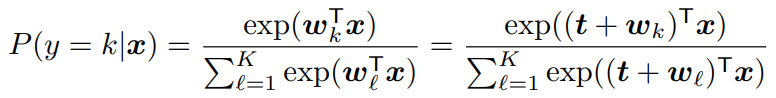

Persamaan likelihood softmaxe regression:

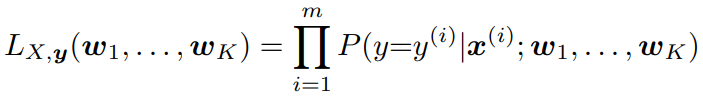

Proses memaksimalkan persamaan likelihood juga sama seperti pada logistic regression, yaitu dengan gradient ascent.

**Sumber gambar:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasi Softmax Regression menggunakan **sklearn** dapat dilihat pada link [berikut](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

Note: sama dengan link yang ada pada bagian Logistic Regression

Dataset Source: https://www.kaggle.com/datasets/supportvectorsailab/flaglike

In [92]:
df_softmax = pd.read_csv('flag.csv')
df_softmax.head()

,x1,x2,t
0,5.056366,0.939336,0.0
1,2.981938,-79.924557,0.0
2,4.665495,-96.107950,0.0
3,2.218880,26.874929,0.0
4,4.275082,-81.303200,0.0


In [93]:
df_softmax.t.value_counts()

t
2.0    2459
0.0    2000
1.0    1856
Name: count, dtype: int64

In [94]:
print(df_softmax.isna().any())
print()
print(f'Length of the data: {len(df_softmax)}')
print()
df_softmax.info()

x1    False
x2    False
t     False
dtype: bool

Length of the data: 6315

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6315 entries, 0 to 6314
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      6315 non-null   float64
 1   x2      6315 non-null   float64
 2   t       6315 non-null   float64
dtypes: float64(3)
memory usage: 148.1 KB


In [95]:
X_softmax = df_softmax.drop(columns=['t'])
y_softmax = df_softmax.t

6. a) Bagi data ke dalam training dan test set dengan ukuran training sebesar 80% dari jumlah data.

In [96]:
from sklearn.model_selection import train_test_split


X_train_soft, X_test_soft, y_train_soft, y_test_soft = train_test_split(
    X_softmax, y_softmax, test_size=0.2, random_state=42, stratify=y_softmax
)

print(f"X_train shape : {X_train_soft.shape}")
print(f"X_test shape  : {X_test_soft.shape}")
print(f"y_train shape : {y_train_soft.shape}")
print(f"y_test shape  : {y_test_soft.shape}")



X_train shape : (5052, 2)
X_test shape  : (1263, 2)
y_train shape : (5052,)
y_test shape  : (1263,)


6. b) Lakukan normalisasi pada data.

In [97]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_soft = StandardScaler()

X_train_soft_scaled = scaler_soft.fit_transform(X_train_soft)
X_test_soft_scaled = scaler_soft.transform(X_test_soft)

X_train_soft_scaled_df = pd.DataFrame(X_train_soft_scaled, columns=X_train_soft.columns)
X_test_soft_scaled_df = pd.DataFrame(X_test_soft_scaled, columns=X_test_soft.columns)

print(f"X_train_scaled shape: {X_train_soft_scaled_df.shape}")
print(f"X_test_scaled shape : {X_test_soft_scaled_df.shape}")

X_train_scaled shape: (5052, 2)
X_test_scaled shape : (1263, 2)


6. c) Buatlah suatu model softmax regression yang dilatih menggunakan data yang sebelumnya telah dinormalisasi serta tampilkan `hasil prediksi`, `confusion matrix`, dan `hasil evaluasi metriknya`. Setelah itu, lakukan **cross validation** untuk menilai performa sebenarnya dari model yang ada.

>`hasil evaluasi metriknya` mencakup:
* F1 Macro Average,
* F1 Micro Average,
* Precision Macro Average
* Precision Micro Average
* Recall Macro Average
* Recall Micro Average

> Scoring dari cross validation:
* Accuracy
* F1 Macro
* Recall Macro

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# Buat model Softmax Regression (multi-class logistic regression)
softmax_clf = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
)
softmax_clf.fit(X_train_soft_scaled_df, y_train_soft)

# Prediksi pada data uji
y_pred_soft = softmax_clf.predict(X_test_soft_scaled_df)

# Confusion matrix
cm_soft = confusion_matrix(y_test_soft, y_pred_soft)

# Metrik evaluasi (macro & micro)
acc = accuracy_score(y_test_soft, y_pred_soft)
f1_macro = f1_score(y_test_soft, y_pred_soft, average='macro')
f1_micro = f1_score(y_test_soft, y_pred_soft, average='micro')
prec_macro = precision_score(y_test_soft, y_pred_soft, average='macro', zero_division=0)
prec_micro = precision_score(y_test_soft, y_pred_soft, average='micro', zero_division=0)
rec_macro = recall_score(y_test_soft, y_pred_soft, average='macro')
rec_micro = recall_score(y_test_soft, y_pred_soft, average='micro')

print("\nHasil Prediksi (head):")
print(pd.DataFrame({
    "Actual": y_test_soft.values,
    "Pred"  : y_pred_soft
}).head(20).to_string(index=False))

print("\nConfusion Matrix:")
print(pd.DataFrame(cm_soft))

print("\nMetrik Evaluasi (Test Set):")
print(f"Accuracy              : {acc:.4f}")
print(f"F1 Macro Average      : {f1_macro:.4f}")
print(f"F1 Micro Average      : {f1_micro:.4f}")
print(f"Precision Macro Avg   : {prec_macro:.4f}")
print(f"Precision Micro Avg   : {prec_micro:.4f}")
print(f"Recall Macro Avg      : {rec_macro:.4f}")
print(f"Recall Micro Avg      : {rec_micro:.4f}")


# ---------------- Cross Validation (train set) ----------------
print("\nCross Validation (Train set, 10-fold)")
print("=" * 80)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores_softmax = cross_validate(
    softmax_clf, X_train_soft_scaled_df, y_train_soft,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "recall_macro": "recall_macro"
    },
    n_jobs=-1,
    return_train_score=False
)

print(f"Accuracy   : mean={cv_scores_softmax['test_accuracy'].mean():.4f}  std={cv_scores_softmax['test_accuracy'].std():.4f}")
print(f"F1 Macro   : mean={cv_scores_softmax['test_f1_macro'].mean():.4f}  std={cv_scores_softmax['test_f1_macro'].std():.4f}")
print(f"Recall Macro: mean={cv_scores_softmax['test_recall_macro'].mean():.4f}  std={cv_scores_softmax['test_recall_macro'].std():.4f}")



Hasil Prediksi (head):
 Actual  Pred
    0.0   2.0
    2.0   2.0
    0.0   0.0
    1.0   1.0
    1.0   1.0
    1.0   0.0
    0.0   2.0
    1.0   1.0
    2.0   2.0
    1.0   1.0
    2.0   0.0
    0.0   2.0
    1.0   1.0
    0.0   2.0
    2.0   0.0
    0.0   1.0
    0.0   2.0
    0.0   1.0
    1.0   1.0
    2.0   2.0

Confusion Matrix:
    0    1    2
0  89  180  131
1  88  236   47
2  98   24  370

Metrik Evaluasi (Test Set):
Accuracy              : 0.5503
F1 Macro Average      : 0.5191
F1 Micro Average      : 0.5503
Precision Macro Avg   : 0.5117
Precision Micro Avg   : 0.5503
Recall Macro Avg      : 0.5369
Recall Micro Avg      : 0.5503

Cross Validation (Train set, 10-fold)
Accuracy   : mean=0.5624  std=0.0138
F1 Macro   : mean=0.5317  std=0.0107
Recall Macro: mean=0.5496  std=0.0132


6. d) Berikan analisis mengenai perbedaan antara regresi softmax dengan regresi logistik.

Jawaban:

Perbedaan utama antara regresi logistik dan regresi softmax terletak pada jumlah kelas yang diprediksi dan cara model menghitung probabilitas tiap kelas. Regresi logistik digunakan untuk kasus klasifikasi biner (2 kelas), sedangkan regresi softmax merupakan perluasan dari regresi logistik untuk klasifikasi multikelas (lebih dari 2 kelas).

Pada regresi logistik, model hanya menghitung probabilitas terhadap satu kelas positif dengan fungsi sigmoid, yaitu menghasilkan nilai antara 0 dan 1 yang menunjukkan peluang suatu sampel termasuk ke dalam kelas positif. Sebaliknya, regresi softmax menggunakan fungsi softmax untuk menghasilkan probabilitas untuk setiap kelas secara bersamaan, di mana semua probabilitas akan berjumlah 1. Dalam hal ini, kelas dengan probabilitas tertinggi akan dipilih sebagai hasil prediksi.

Secara konsep, regresi softmax memungkinkan model untuk menangani hubungan saling eksklusif antar kelas dan memutuskan di antara lebih dari dua kategori secara langsung, bukan dengan pendekatan “one-vs-rest” seperti pada regresi logistik biner. Dengan demikian, regresi logistik cocok untuk masalah dua kelas, sedangkan regresi softmax digunakan ketika data memiliki tiga kelas atau lebih, seperti pada hasil klasifikasi data “flag” di atas.

# **Kaggle Competition**

Dalam rangka menerapkan pemahaman kalian pada materi Linear Model, kalian **diwajibkan** untuk mengikuti Kaggle Competition yang akan diadakan bersamaan dengan Lab 5 ini.

**Bagaimana Cara Mengikuti?**
- Join ke kompetisi di bagian bawah ini. Klik tautan tersebut untuk mengakses halaman kompetisi.
- Kerjakan solusi Anda menggunakan notebook ini. Template kode tersedia dibawah.
- Unggah hasil prediksi Anda ke dalam kompetisi Kaggle yang telah disediakan. Format dari submission telah dispesifikasikan pada bagian **Submission File** di laman Kaggle.
- Model yang boleh digunakan hanya model yang diajarkan di lab ini.
- Boleh menggunakan teknik hyperparameter tuning lainnya selain yang diajarkan di kelas/lab.
- Submission File harus sesuai dengan yang dihasilkan oleh model pada Notebook.

**Tautan Kaggle Competition**
- [Kaggle Competition - LAB 5 - Linear Model](https://www.kaggle.com/competitions/klasifikasi-lab-5-linear-model)

**Penilaian**

Untuk mendapatkan nilai penuh pada lab 5 ini, kalian **diwajibkan** untuk mengikuti kompetisi Kaggle di atas.

## EDA


--- INFORMASI DATA ---
Train shape: (288, 18)
Test shape : (124, 17)

Kolom Train: ['ID', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Kolom Test : ['ID', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

Tipe data Train:
ID                 int64
Drug              object
Age              float64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage              int64
dtype: object

--- MISSING VALUES ---
Tryglice

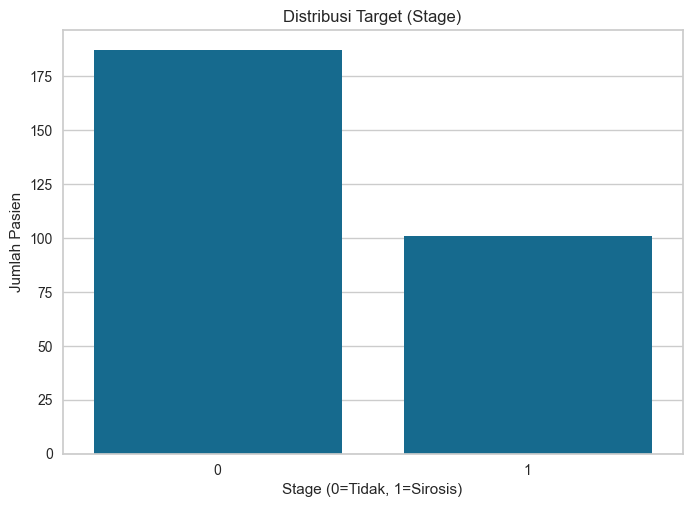


--- NILAI UNIK KATEGORIKAL ---

Drug: ['D-penicillamine' 'Placebo' 'No Drug']

Sex: ['F' 'M']

Ascites: ['Y' 'N' nan]

Hepatomegaly: ['Y' 'N' nan]

Spiders: ['Y' 'N' nan]

Edema: ['Y' 'N' 'S']

--- KORELASI FITUR NUMERIK DENGAN TARGET ---
               Correlation
Prothrombin       0.306818
Age               0.271820
Copper            0.235926
Bilirubin         0.232704
SGOT              0.080823
Tryglicerides     0.007043
Alk_Phos         -0.030342
ID               -0.070247
Cholesterol      -0.132832
Platelets        -0.295710


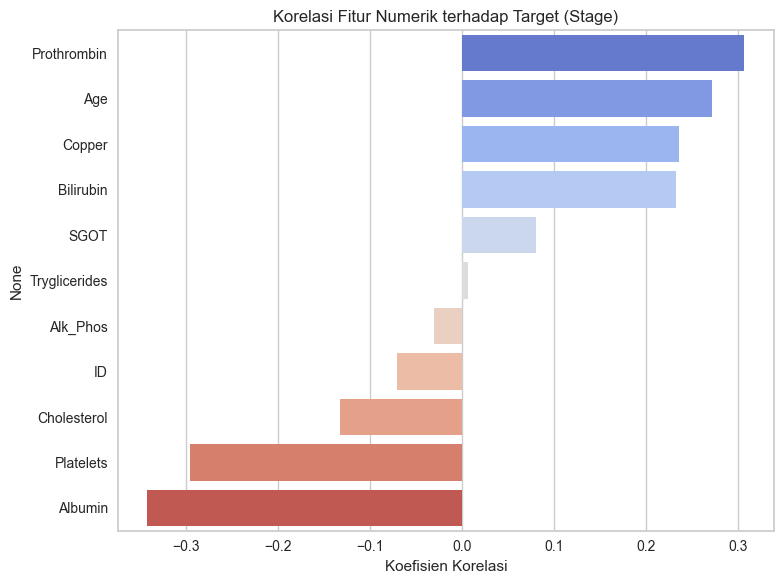

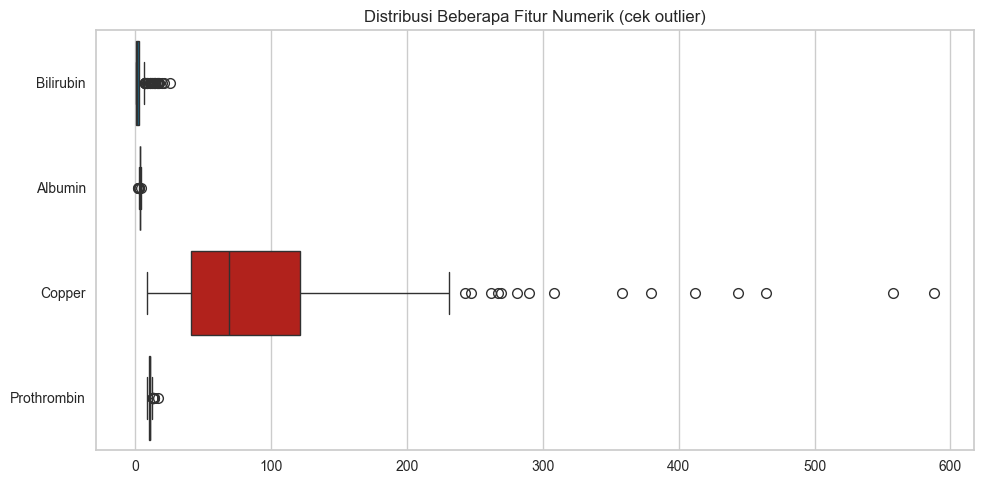


--- PERBANDINGAN RATA-RATA FITUR UTAMA BERDASARKAN STAGE ---
       Bilirubin   Albumin      Copper  Prothrombin
Stage                                              
0       2.297861  3.630749   82.517241    10.514439
1       4.259406  3.340990  127.556962    11.144554


In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Baca data
train = pd.read_csv('cirrhosis_train.csv')
test = pd.read_csv('cirrhosis_test.csv')

print("\n--- INFORMASI DATA ---")
print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\nKolom Train:", list(train.columns))
print("Kolom Test :", list(test.columns))

print("\nTipe data Train:")
print(train.dtypes)

# Cek missing values
print("\n--- MISSING VALUES ---")
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train)

# persentase missing
if len(missing_train) > 0:
    print("\nPersentase missing value:")
    print((missing_train / len(train) * 100).round(2))

# Deskripsi statistik
print("\n--- DESKRIPSI STATISTIK (Numerik) ---")
print(train.describe().T)

# Distribusi target
print("\n--- DISTRIBUSI TARGET (Stage) ---")
print(train['Stage'].value_counts())
sns.countplot(x='Stage', data=train)
plt.title('Distribusi Target (Stage)')
plt.xlabel('Stage (0=Tidak, 1=Sirosis)')
plt.ylabel('Jumlah Pasien')
plt.show()

# Cek nilai unik kolom kategorikal
print("\n--- NILAI UNIK KATEGORIKAL ---")
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}: {train[col].unique()}")

# Analisis Korelasi antar fitur numerik
print("\n--- KORELASI FITUR NUMERIK DENGAN TARGET ---")
num_cols = train.select_dtypes(include=[np.number]).columns.drop('Stage', errors='ignore')
corr = train[num_cols].corrwith(train['Stage'])
corr_df = corr.sort_values(ascending=False).to_frame('Correlation')
print(corr_df.head(10))

plt.figure(figsize=(8,6))
sns.barplot(x=corr_df['Correlation'], y=corr_df.index, palette='coolwarm')
plt.title('Korelasi Fitur Numerik terhadap Target (Stage)')
plt.xlabel('Koefisien Korelasi')
plt.tight_layout()
plt.show()


# Analisis outlier sederhana (boxplot)
plt.figure(figsize=(10,5))
sns.boxplot(data=train[['Bilirubin', 'Albumin', 'Copper', 'Prothrombin']], orient='h')
plt.title('Distribusi Beberapa Fitur Numerik (cek outlier)')
plt.tight_layout()
plt.show()

# Cek perbandingan rata-rata fitur penting antar kelas
print("\n--- PERBANDINGAN RATA-RATA FITUR UTAMA BERDASARKAN STAGE ---")
mean_by_stage = train.groupby('Stage')[['Bilirubin', 'Albumin', 'Copper', 'Prothrombin']].mean()
print(mean_by_stage)


## Preprocessing

In [103]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load data
train = pd.read_csv('cirrhosis_train.csv')
test = pd.read_csv('cirrhosis_test.csv')

print("=== Sebelum Preprocessing ===")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

# Simpan ID test untuk output
test_ID = test['ID']

# Hapus kolom ID
train.drop(columns=['ID'], inplace=True)
test.drop(columns=['ID'], inplace=True)

# Pisahkan kolom numerik dan kategorikal
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

print("\nKolom numerik:", num_cols)
print("Kolom kategorikal:", cat_cols)

# Salinan data
train_copy = train.copy()
test_copy = test.copy()

# === 1. Isi missing value kategorikal (pakai mode) ===
for col in cat_cols:
    mode_val = train_copy[col].mode()[0]
    train_copy[col].fillna(mode_val, inplace=True)
    if col in test_copy.columns:
        test_copy[col].fillna(mode_val, inplace=True)

# === 2. Encode kategori jadi numerik sementara (untuk KNN) ===
train_tmp = train_copy.copy()
test_tmp = test_copy.copy()
for col in cat_cols:
    mapping = {v: i for i, v in enumerate(train_tmp[col].unique())}
    train_tmp[col] = train_tmp[col].map(mapping)
    if col in test_tmp.columns:
        test_tmp[col] = test_tmp[col].map(mapping)
    else:
        test_tmp[col] = np.nan

# === 3. Drop kolom target sebelum imputasi ===
train_features = train_tmp.drop(columns=['Stage'])
test_features = test_tmp.copy()

# Samakan urutan kolom
test_features = test_features[train_features.columns]

# === 4. KNN Imputer ===
imputer = KNNImputer(n_neighbors=5, weights='distance')
train_imputed_features = pd.DataFrame(imputer.fit_transform(train_features), columns=train_features.columns)
test_imputed = pd.DataFrame(imputer.transform(test_features), columns=test_features.columns)

# Tambahkan kembali target
train_imputed = train_imputed_features.copy()
train_imputed['Stage'] = train_tmp['Stage']

# === 5. Pisahkan fitur dan target ===
X_train = train_imputed.drop(columns=['Stage'])
y_train = train_imputed['Stage'].round().astype(int)
X_test = test_imputed.copy()

# === 6. One-Hot Encoding ===
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = pd.DataFrame(ohe.fit_transform(train_copy[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))
X_test_cat = pd.DataFrame(ohe.transform(test_copy[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))

# === 7. Ambil fitur numerik ===
X_train_num = X_train.drop(columns=cat_cols, errors='ignore')
X_test_num = X_test.drop(columns=cat_cols, errors='ignore')

# === 8. Feature Engineering tambahan ===
X_train_num['Bilirubin_Albumin_Ratio'] = X_train_num['Bilirubin'] / (X_train_num['Albumin'] + 1e-5)
X_test_num['Bilirubin_Albumin_Ratio'] = X_test_num['Bilirubin'] / (X_test_num['Albumin'] + 1e-5)

X_train_num['Copper_Prothrombin_Ratio'] = X_train_num['Copper'] / (X_train_num['Prothrombin'] + 1e-5)
X_test_num['Copper_Prothrombin_Ratio'] = X_test_num['Copper'] / (X_test_num['Prothrombin'] + 1e-5)

X_train_num['Alk_SGOT_Ratio'] = X_train_num['Alk_Phos'] / (X_train_num['SGOT'] + 1e-5)
X_test_num['Alk_SGOT_Ratio'] = X_test_num['Alk_Phos'] / (X_test_num['SGOT'] + 1e-5)

X_train_num['Age_Albumin_Ratio'] = X_train_num['Age'] / (X_train_num['Albumin'] + 1e-5)
X_test_num['Age_Albumin_Ratio'] = X_test_num['Age'] / (X_test_num['Albumin'] + 1e-5)

# === 9. Gabungkan numerik + kategori ===
X_train_final = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_num.reset_index(drop=True), X_test_cat.reset_index(drop=True)], axis=1)

# === 10. Normalisasi ===
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns)

# === 11. Cek hasil akhir ===
print("\n=== Setelah Preprocessing ===")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape : {X_test_scaled.shape}")
print(f"y_train shape       : {y_train.shape}")

print("\nCek apakah masih ada missing:")
print("Train missing total:", X_train_scaled.isna().sum().sum())
print("Test missing total :", X_test_scaled.isna().sum().sum())


=== Sebelum Preprocessing ===
Train shape: (288, 18), Test shape: (124, 17)

Kolom numerik: ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Kolom kategorikal: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

=== Setelah Preprocessing ===
X_train_scaled shape: (288, 28)
X_test_scaled shape : (124, 28)
y_train shape       : (288,)

Cek apakah masih ada missing:
Train missing total: 0
Test missing total : 0


## Modeling

In [106]:
# === MODELLING: Logistic Regression + CV untuk k & C ===
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import pandas as pd

print("\n=== MODEL SELECTION DENGAN GRIDSEARCHCV ===")

pipe = Pipeline([
    ("fs", SelectKBest(score_func=f_classif, k=20)),   # placeholder k, akan di-grid
    ("clf", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

param_grid = {
    "fs__k": [10, 12, 15, 18, 20, 25, "all"],
    "clf__C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    "clf__class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",        # target utamanya accuracy
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(X_train_scaled, y_train)

print(f"Best CV Accuracy : {grid.best_score_:.4f}")
print("Best Params      :", grid.best_params_)

# Evaluasi di training (fit sudah dilakukan pada seluruh train dengan params terbaik)
y_pred_train = grid.predict(X_train_scaled)
print("\n=== EVALUASI TRAINING (BEST MODEL) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train))
print("\nClassification Report:")
print(classification_report(y_train, y_pred_train, digits=4))
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")

# Cross-validation ulang untuk ringkasan metrik lain (macro F1, macro recall)
cv_acc = cross_val_score(grid.best_estimator_, X_train_scaled, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
cv_f1  = cross_val_score(grid.best_estimator_, X_train_scaled, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
cv_rec = cross_val_score(grid.best_estimator_, X_train_scaled, y_train, cv=cv, scoring="recall_macro", n_jobs=-1)

print("\n=== CROSS VALIDATION (10-Fold, Best Model) ===")
print(f"Accuracy   : mean={cv_acc.mean():.4f}  std={cv_acc.std():.4f}")
print(f"F1 Macro   : mean={cv_f1.mean():.4f}  std={cv_f1.std():.4f}")
print(f"Recall Macro: mean={cv_rec.mean():.4f}  std={cv_rec.std():.4f}")

# Prediksi test & simpan CSV
y_pred_test = grid.predict(X_test_scaled).astype(int)

output = pd.DataFrame({"ID": test_ID, "Stage": y_pred_test})
output.to_csv("cirrhosis_predictions6.csv", index=False)

print("\n=== HASIL PREDIKSI TEST ===")
print(output.head(10))
print("\nFile hasil prediksi berhasil disimpan: cirrhosis_predictions.csv")



=== MODEL SELECTION DENGAN GRIDSEARCHCV ===
Best CV Accuracy : 0.7847
Best Params      : {'clf__C': 2, 'clf__class_weight': None, 'fs__k': 25}

=== EVALUASI TRAINING (BEST MODEL) ===
Confusion Matrix:
[[163  24]
 [ 34  67]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8274    0.8717    0.8490       187
           1     0.7363    0.6634    0.6979       101

    accuracy                         0.7986       288
   macro avg     0.7818    0.7675    0.7734       288
weighted avg     0.7954    0.7986    0.7960       288

Train Accuracy: 0.7986

=== CROSS VALIDATION (10-Fold, Best Model) ===
Accuracy   : mean=0.7847  std=0.0613
F1 Macro   : mean=0.7542  std=0.0743
Recall Macro: mean=0.7503  std=0.0740

=== HASIL PREDIKSI TEST ===
   ID  Stage
0   1      1
1   2      0
2   3      1
3   4      0
4   5      0
5   6      1
6   7      0
7   8      0
8   9      0
9  10      0

File hasil prediksi berhasil disimpan: cirrhosis_predictions.csv
